In [163]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [164]:
fear = pd.read_csv("fear_greed_index.csv")
historical = pd.read_csv("historical_data.csv")

In [165]:
print(fear.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05


In [166]:
print(historical.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [167]:
print(fear.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [168]:
print(historical.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [169]:
print(fear.info())
print(historical.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 n

In [170]:
# Fixing column names
historical.columns = historical.columns.str.strip().str.lower().str.replace(" ", "_")

In [171]:
fear.columns = fear.columns.str.strip().str.lower()

In [172]:
print(historical)

                                           account      coin  execution_price  \
0       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9769   
1       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9800   
2       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9855   
3       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9874   
4       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9894   
...                                            ...       ...              ...   
211219  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211220  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211221  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211222  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211223  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   

        size_tokens  size_u

In [173]:
print(fear)

       timestamp  value classification        date
0     1517463000     30           Fear  2018-02-01
1     1517549400     15   Extreme Fear  2018-02-02
2     1517635800     40           Fear  2018-02-03
3     1517722200     24   Extreme Fear  2018-02-04
4     1517808600     11   Extreme Fear  2018-02-05
...          ...    ...            ...         ...
2639  1745818200     54        Neutral  2025-04-28
2640  1745904600     60          Greed  2025-04-29
2641  1745991000     56          Greed  2025-04-30
2642  1746077400     53        Neutral  2025-05-01
2643  1746163800     67          Greed  2025-05-02

[2644 rows x 4 columns]


In [174]:
# Converting timestamps
fear['date'] = pd.to_datetime(fear['date'])

In [175]:
print(fear['date'])

0      2018-02-01
1      2018-02-02
2      2018-02-03
3      2018-02-04
4      2018-02-05
          ...    
2639   2025-04-28
2640   2025-04-29
2641   2025-04-30
2642   2025-05-01
2643   2025-05-02
Name: date, Length: 2644, dtype: datetime64[ns]


In [176]:
historical['timestamp_ist'] = pd.to_datetime(
    historical['timestamp_ist'],
    dayfirst=True
)

In [177]:
historical['timestamp_ist'].isnull().sum()

np.int64(0)

In [178]:
print(historical['timestamp_ist'].head())
print(historical['timestamp_ist'].dtype)

0   2024-12-02 22:50:00
1   2024-12-02 22:50:00
2   2024-12-02 22:50:00
3   2024-12-02 22:50:00
4   2024-12-02 22:50:00
Name: timestamp_ist, dtype: datetime64[ns]
datetime64[ns]


In [179]:
# Creating date column in both the dataset
historical['date'] = historical['timestamp_ist'].dt.date

In [180]:
fear['date'] = pd.to_datetime(fear['date']).dt.date

In [181]:
print(historical[['timestamp_ist', 'date']].head())

        timestamp_ist        date
0 2024-12-02 22:50:00  2024-12-02
1 2024-12-02 22:50:00  2024-12-02
2 2024-12-02 22:50:00  2024-12-02
3 2024-12-02 22:50:00  2024-12-02
4 2024-12-02 22:50:00  2024-12-02


In [182]:
print(fear[['date', 'classification']].head())

         date classification
0  2018-02-01           Fear
1  2018-02-02   Extreme Fear
2  2018-02-03           Fear
3  2018-02-04   Extreme Fear
4  2018-02-05   Extreme Fear


In [183]:
print(historical['date'].min(), historical['date'].max())

2023-05-01 2025-05-01


In [184]:
print(fear['date'].min(), fear['date'].max())

2018-02-01 2025-05-02


In [185]:
# Merging
merged = historical.merge(fear[['date', 'classification']], on='date', how='inner')

In [186]:
print(merged.shape)
print(merged.head())
print(merged['classification'].value_counts())

(211218, 18)
                                      account  coin  execution_price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   size_tokens  size_usd side       timestamp_ist  start_position direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   closed_pnl                                   transaction_hash     order_id  

In [187]:
# Daily PnL per trader
daily_pnl = merged.groupby(['account', 'date'])['closed_pnl'].sum().reset_index()
print(daily_pnl)

# Leverage data was not available in the dataset; hence, trade size (USD) was used as a proxy for risk exposure.

                                         account        date    closed_pnl
0     0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-11      0.000000
1     0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-17      0.000000
2     0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-18      0.000000
3     0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-22 -21227.000000
4     0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-26   1603.100000
...                                          ...         ...           ...
2335  0xbee1707d6b44d4d52bfe19e41f8a828645437aab  2025-04-27   1709.194807
2336  0xbee1707d6b44d4d52bfe19e41f8a828645437aab  2025-04-28   4008.588908
2337  0xbee1707d6b44d4d52bfe19e41f8a828645437aab  2025-04-29   8561.771838
2338  0xbee1707d6b44d4d52bfe19e41f8a828645437aab  2025-04-30   2520.773814
2339  0xbee1707d6b44d4d52bfe19e41f8a828645437aab  2025-05-01   1364.022527

[2340 rows x 3 columns]


In [188]:
# Number of trades per day
trades_per_day = merged.groupby('date').size().reset_index(name='trade_count')
print(trades_per_day)

           date  trade_count
0    2023-05-01            3
1    2023-12-05            9
2    2023-12-14           11
3    2023-12-15            2
4    2023-12-16            3
..          ...          ...
474  2025-04-27          337
475  2025-04-28         1379
476  2025-04-29         2243
477  2025-04-30         1113
478  2025-05-01         1230

[479 rows x 2 columns]


In [189]:
# Creating WIN column
merged['win'] = merged['closed_pnl'] > 0

In [190]:
# Checking Pnl behaviour
print(merged['closed_pnl'].describe())


count    211218.000000
mean         48.549304
std         917.989791
min     -117990.104100
25%           0.000000
50%           0.000000
75%           5.790132
max      135329.090100
Name: closed_pnl, dtype: float64


In [191]:
# Compute average PnL by sentiment
merged.groupby('classification')['closed_pnl'].mean()

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: closed_pnl, dtype: float64

In [192]:
# Compute win rate by sentiment
merged.groupby('classification')['win'].mean()

classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64

From the above insight

Traders perform best in Extreme Greed and Traders perform worst in Extreme Fear

Even in best case, win rate is < 50%

That means:

Traders lose more often than they win — profits come from bigger wins, not higher accuracy

In [193]:
# Analyzing behaviour vs sentiment

In [194]:
# Trend count
merged.groupby('classification').size()

classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64

In [195]:
# Average trade size
merged.groupby('classification')['size_usd'].mean()

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: size_usd, dtype: float64

In [196]:
# Long short behaviour
pd.crosstab(merged['classification'], merged['side'])

side,BUY,SELL
classification,,
Extreme Fear,10935,10465
Extreme Greed,17940,22052
Fear,30270,31567
Greed,24576,25727
Neutral,18969,18717


From the above insight, we have observed that,

During Fear:

More trades
Larger positions
But NOT best performance

During Extreme Greed:

Fewer trades
Smaller positions
Best performance

Traders behave aggressively during Fear (high activity + large positions), but this does not translate into better performance. In contrast, during Extreme Greed, traders reduce position size and activity, yet achieve higher profitability and win rates.

In [197]:
# Create trader segments
# High leverage vs Low leverage traders
threshold = merged['size_usd'].median()

merged['size_group'] = np.where(merged['size_usd'] > threshold,'High','Low')

In [198]:
# 2. Frequent vs Infrequent traders
freq = merged['account'].value_counts()
threshold = freq.median()

merged['trader_type'] = merged['account'].map(lambda x: 'Frequent' if freq[x] > threshold else 'Infrequent')

In [199]:
# Consistent Winners vs Inconsistent Traders
pnl_total = merged.groupby('account')['closed_pnl'].sum()

merged['profitability'] = merged['account'].map(lambda x: 'Consistent Winners' if pnl_total[x] > 0 else 'Incosistent traders')

In [200]:
# Performance of high leverage vs low leverage traders
merged.groupby(['size_group', 'classification'])['closed_pnl'].mean().unstack()

classification,Extreme Fear,Extreme Greed,Fear,Greed,Neutral
size_group,,,,,
High,61.196379,140.570044,97.025581,84.301244,69.581271
Low,1.157202,9.628661,3.580906,3.609685,2.188668


In [201]:
# Win rate of high leverage vs low leverage traders
merged.groupby(['size_group', 'classification'])['win'].mean().unstack()

classification,Extreme Fear,Extreme Greed,Fear,Greed,Neutral
size_group,,,,,
High,0.401832,0.427536,0.428912,0.400803,0.406548
Low,0.331509,0.494932,0.411103,0.369784,0.388289


In [202]:
# Performance of frequent vs infrequent traders
merged.groupby(['trader_type', 'classification'])['closed_pnl'].mean().unstack()

classification,Extreme Fear,Extreme Greed,Fear,Greed,Neutral
trader_type,,,,,
Frequent,34.163353,62.870911,51.323784,25.004641,34.579701
Infrequent,35.941979,103.264685,80.835791,210.210287,31.845656


In [203]:
# Win rate of frequent vs infrequent traders
merged.groupby(['trader_type', 'classification'])['win'].mean().unstack()

classification,Extreme Fear,Extreme Greed,Fear,Greed,Neutral
trader_type,,,,,
Frequent,0.373683,0.478898,0.424893,0.382192,0.399800
Infrequent,0.359077,0.366653,0.383848,0.409714,0.371566


In [204]:
# Trade size of Consistent Winners vs Inconsistent Traders
merged.groupby('profitability')['size_usd'].mean()

profitability
Consistent Winners     5671.838495
Incosistent traders    4924.346943
Name: size_usd, dtype: float64

In [205]:
# Trade frequency of Consistent Winners vs Inconsistent Traders
merged.groupby('profitability').size()

profitability
Consistent Winners     201993
Incosistent traders      9225
dtype: int64

In [206]:
merged['loss'] = merged['closed_pnl'].apply(lambda x: x if x < 0 else 0)

drawdown = merged.groupby('classification')['loss'].mean()
print(drawdown)

classification
Extreme Fear    -29.734653
Extreme Greed    -6.773853
Fear             -9.599331
Greed           -21.046179
Neutral         -10.329716
Name: loss, dtype: float64


Average losses (drawdown proxy) are highest during Fear/Extreme Fear phases, indicating higher downside risk in bearish sentiment.

INSIGHT 1:  “Bigger trades is not equal to  safer trades”

The above data shows:
High trade size leads to massively higher PnL

BUT win rate:
High size is approximately 40 to 42%
Low size can even hit apprximantely 49% (Extreme Greed)

Summary:

Larger trades generate higher profits, but they do NOT increase win probability — profitability comes from larger winning trades, not accuracy.

INSIGHT 2: “Overtrading kills performance”
    
The above data shows:
    
Frequent traders:
Lower PnL (e.g. Greed: 25 vs 210 for infrequent huge gap)
Win rate not significantly better

Infrequent traders:
Much higher profitability
Comparable or better efficiency

Summary:

Frequent traders underperform significantly compared to infrequent traders, suggesting overtrading reduces profitability without improving win rates.

INSIGHT 3: “Best performance comes from controlled behavior, not aggression”
    
Fear:
High activity
Large trade sizes
NOT best performance

Extreme Greed:
Lower trade size
Better win rate
Highest PnL

Summary:

Traders achieve better performance when they reduce trade size and act more selectively (Extreme Greed), whereas aggressive behavior during Fear leads to suboptimal outcomes.

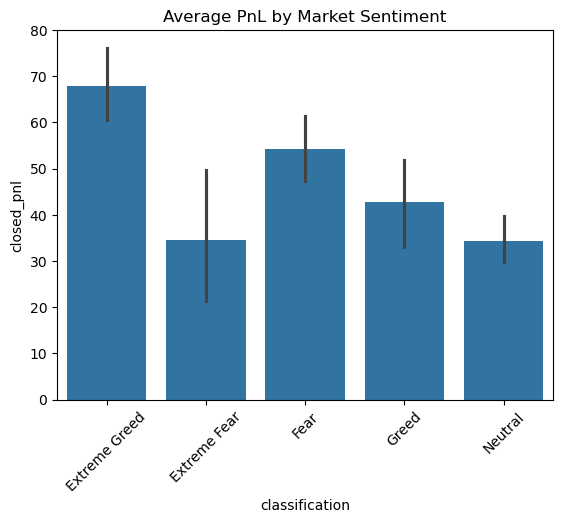

In [207]:
# PnL vs Sentiment

sns.barplot(x='classification', y='closed_pnl', data=merged)
plt.title("Average PnL by Market Sentiment")
plt.xticks(rotation=45)
plt.show()

Average PnL is highest during Extreme Greed and lowest during Extreme Fear. This indicates that traders perform significantly better in strong bullish sentiment, while fearful market conditions negatively impact profitability.

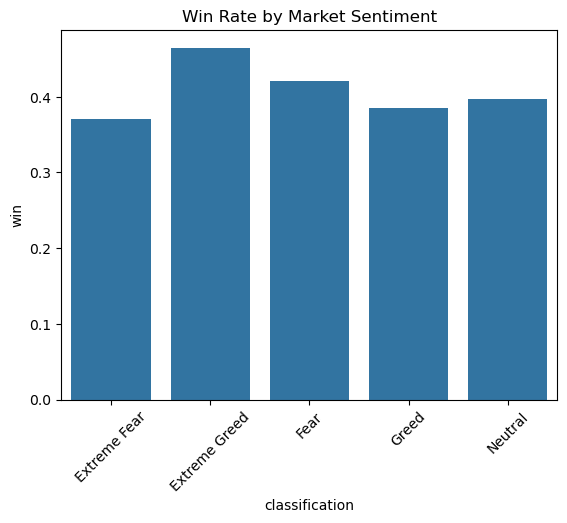

In [208]:
# Win Rate vs Sentiment
win_rate = merged.groupby('classification')['win'].mean().reset_index()

sns.barplot(x='classification', y='win', data=win_rate)
plt.title("Win Rate by Market Sentiment")
plt.xticks(rotation=45)
plt.show()

Win rate follows a similar trend, peaking during Extreme Greed and dropping during Extreme Fear. However, win rates remain below 50% across all sentiments, suggesting profitability is driven by larger winning trades rather than higher accuracy.

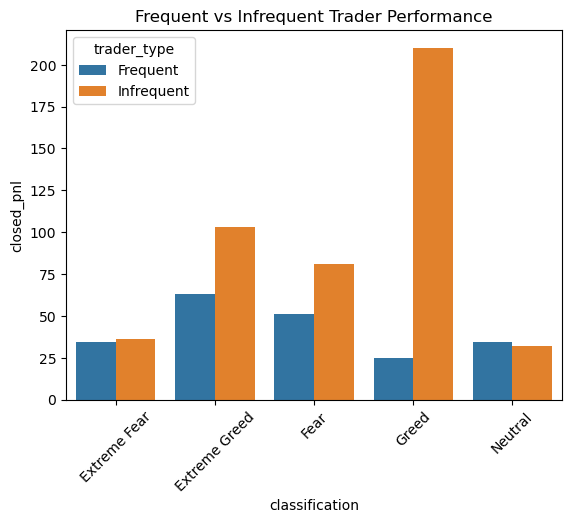

In [209]:
# Frequent vs Infrequent (PnL)
pnl_trader = merged.groupby(['trader_type', 'classification'])['closed_pnl'].mean().reset_index()

sns.barplot(x='classification', y='closed_pnl', hue='trader_type', data=pnl_trader)
plt.title("Frequent vs Infrequent Trader Performance")
plt.xticks(rotation=45)
plt.show()

Infrequent traders consistently achieve higher PnL compared to frequent traders, especially during Greed phases. This suggests that overtrading reduces performance, while selective trading leads to better outcomes.

STRATEGY 1: Control Risk During Fear

During Fear and Extreme Fear phases, traders should reduce trade size and avoid aggressive positioning, as higher trade sizes during these periods are associated with lower profitability and win rates.
This suggests that risk-taking behavior in fearful markets leads to suboptimal outcomes, and capital preservation should be prioritized.

STRATEGY 2: Avoid Overtrading, Especially in Greed

Traders should limit trade frequency and focus on selective opportunities, particularly during Greed phases, as infrequent traders consistently outperform frequent traders in terms of profitability without significantly lower win rates.
This indicates that overtrading reduces performance, and disciplined trade selection leads to better outcomes.

STRATEGY 3: Scale Smart in Extreme Greed

During Extreme Greed phases, traders can maintain moderate exposure with controlled trade sizes, as these conditions show the highest profitability and win rates. However, increasing trade size aggressively is not necessary, as performance is driven by efficiency rather than risk intensity.

In [210]:
# Clustering traders into behavioral archetypes
# Creating trader-level dataset
trader_features = merged.groupby('account').agg({
    'closed_pnl': 'mean',
    'size_usd': 'mean',
    'win': 'mean',
    'account': 'count'
}).rename(columns={'account': 'trade_count'}).reset_index()

In [211]:
# Normalize data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(trader_features[['closed_pnl', 'size_usd', 'win', 'trade_count']])

In [212]:
# Apply KMeans
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
trader_features['cluster'] = kmeans.fit_predict(X)

C:\Users\Dell\miniconda3\envs\myenv\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [213]:
# Understand clusters
trader_features.groupby('cluster')[['closed_pnl', 'size_usd', 'win', 'trade_count']].mean()

,closed_pnl,size_usd,win,trade_count
cluster,,,,
0,203.649635,10353.397560,0.439536,4009.000000
1,38.390661,1915.636756,0.379881,20003.833333
2,30.227394,4033.276520,0.381526,3077.642857


Insight

Traders can be grouped into distinct behavioral archetypes based on their trading patterns. One cluster represents high-risk, high-reward traders who use larger position sizes and achieve significantly higher profitability despite only moderate win rates. Another cluster consists of low-risk traders with smaller trade sizes and lower profitability, indicating insufficient exposure to generate meaningful returns. A third group shows moderate behavior across all metrics without a clear performance edge.

This segmentation highlights that profitability is more strongly influenced by position sizing and trade exposure than by win rate alone.